In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
#Global Styles
sns.set_theme(
    style="whitegrid",
    palette="coolwarm"
)

In [3]:
#Load Dataset
df = pd.read_csv("../Dataset/world_population.csv")

In [4]:
#Display the top rows
df.head()

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [5]:
#Understanding data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    str    
 2   Country/Territory            234 non-null    str    
 3   Capital                      234 non-null    str    
 4   Continent                    234 non-null    str    
 5   2022 Population              234 non-null    int64  
 6   2020 Population              234 non-null    int64  
 7   2015 Population              234 non-null    int64  
 8   2010 Population              234 non-null    int64  
 9   2000 Population              234 non-null    int64  
 10  1990 Population              234 non-null    int64  
 11  1980 Population              234 non-null    int64  
 12  1970 Population              234 non-null    int64  
 13  Area (km²)                   23

In [6]:
#Shows summary statistics
df.describe()

,Rank,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
count,234.000000,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,234.000000,234.000000,234.000000
mean,117.500000,3.407441e+07,3.350107e+07,3.172996e+07,2.984524e+07,2.626947e+07,2.271022e+07,1.898462e+07,1.578691e+07,5.814494e+05,452.127044,1.009577,0.427051
std,67.694165,1.367664e+08,1.355899e+08,1.304050e+08,1.242185e+08,1.116982e+08,9.783217e+07,8.178519e+07,6.779509e+07,1.761841e+06,2066.121904,0.013385,1.714977
min,1.000000,5.100000e+02,5.200000e+02,5.640000e+02,5.960000e+02,6.510000e+02,7.000000e+02,7.330000e+02,7.520000e+02,1.000000e+00,0.026100,0.912000,0.000000
25%,59.250000,4.197385e+05,4.152845e+05,4.046760e+05,3.931490e+05,3.272420e+05,2.641158e+05,2.296142e+05,1.559970e+05,2.650000e+03,38.417875,1.001775,0.010000
50%,117.500000,5.559944e+06,5.493074e+06,5.307400e+06,4.942770e+06,4.292907e+06,3.825410e+06,3.141146e+06,2.604830e+06,8.119950e+04,95.346750,1.007900,0.070000
75%,175.750000,2.247650e+07,2.144798e+07,1.973085e+07,1.915957e+07,1.576230e+07,1.186923e+07,9.826054e+06,8.817329e+06,4.304258e+05,238.933250,1.016950,0.280000
max,234.000000,1.425887e+09,1.424930e+09,1.393715e+09,1.348191e+09,1.264099e+09,1.153704e+09,9.823725e+08,8.225344e+08,1.709824e+07,23172.266700,1.069100,17.880000


In [7]:
#Missing values per column
df.isna().sum()

Rank                           0
CCA3                           0
Country/Territory              0
Capital                        0
Continent                      0
2022 Population                0
2020 Population                0
2015 Population                0
2010 Population                0
2000 Population                0
1990 Population                0
1980 Population                0
1970 Population                0
Area (km²)                     0
Density (per km²)              0
Growth Rate                    0
World Population Percentage    0
dtype: int64

In [8]:
#Correlation between numeric columns
df_corr = df.select_dtypes(include = "number").corr()
df_corr

,Rank,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
Rank,1.000000,-0.358361,-0.355854,-0.351222,-0.347461,-0.341057,-0.336152,-0.335246,-0.335379,-0.383774,0.129436,-0.224561,-0.358464
2022 Population,-0.358361,1.000000,0.999946,0.999490,0.998629,0.994605,0.987228,0.980285,0.973162,0.453411,-0.027618,-0.020863,0.999999
2020 Population,-0.355854,0.999946,1.000000,0.999763,0.999105,0.995583,0.988724,0.982121,0.975254,0.454993,-0.027358,-0.025116,0.999944
2015 Population,-0.351222,0.999490,0.999763,1.000000,0.999783,0.997340,0.991594,0.985724,0.979414,0.458240,-0.026857,-0.032154,0.999487
2010 Population,-0.347461,0.998629,0.999105,0.999783,1.000000,0.998593,0.993929,0.988786,0.983042,0.461936,-0.026505,-0.037983,0.998626
2000 Population,-0.341057,0.994605,0.995583,0.997340,0.998593,1.000000,0.998336,0.995160,0.990956,0.473933,-0.026139,-0.050515,0.994598
1990 Population,-0.336152,0.987228,0.988724,0.991594,0.993929,0.998336,1.000000,0.999042,0.996602,0.486764,-0.026224,-0.062397,0.987218
1980 Population,-0.335246,0.980285,0.982121,0.985724,0.988786,0.995160,0.999042,1.000000,0.999194,0.498166,-0.026587,-0.072349,0.980273
1970 Population,-0.335379,0.973162,0.975254,0.979414,0.983042,0.990956,0.996602,0.999194,1.000000,0.509940,-0.026881,-0.081313,0.973150
Area (km²),-0.383774,0.453411,0.454993,0.458240,0.461936,0.473933,0.486764,0.498166,0.509940,1.000000,-0.063128,-0.013970,0.453284


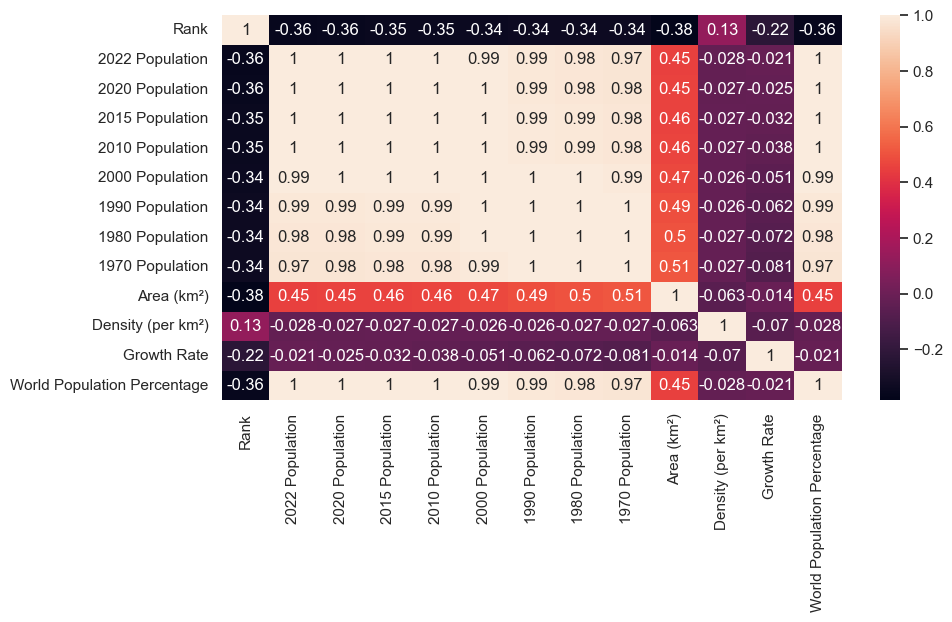

In [9]:
#Heatmap of correlation matrix
plt.figure(figsize=(10,5))
sns.heatmap(df_corr, annot=True)
plt.show()

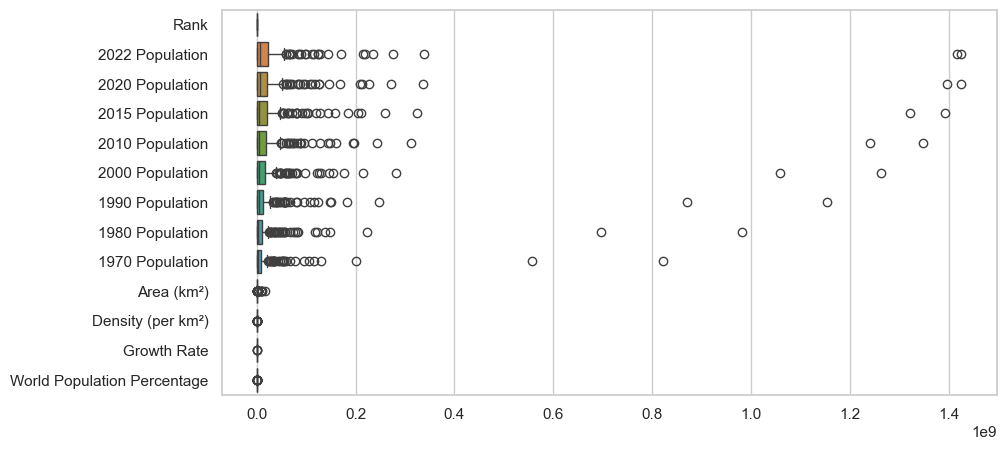

In [10]:
#Horizontal boxplot for numeric columns (outliers check)
plt.figure(figsize=(10,5))
sns.boxplot(data=df, orient="h")
plt.show()

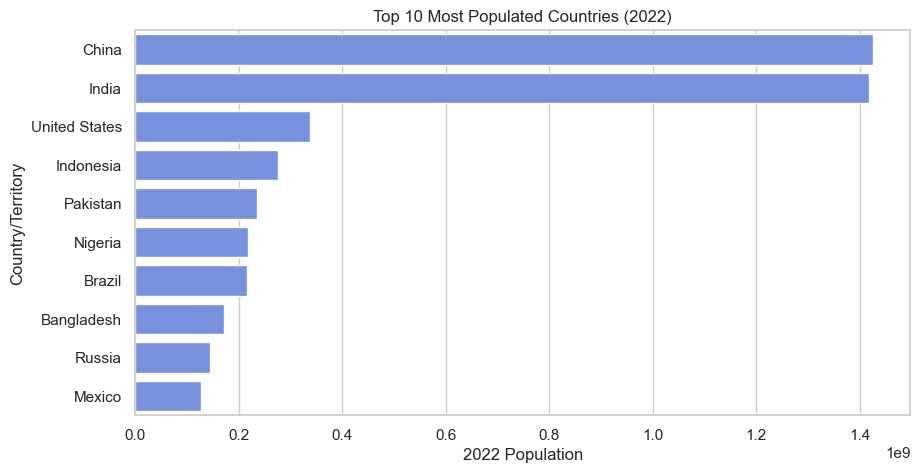

In [11]:
#Top 10 Most Populated Countries (2022)
top10 = df.sort_values("2022 Population", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top10, x="2022 Population", y="Country/Territory")
plt.title("Top 10 Most Populated Countries (2022)")
plt.show()

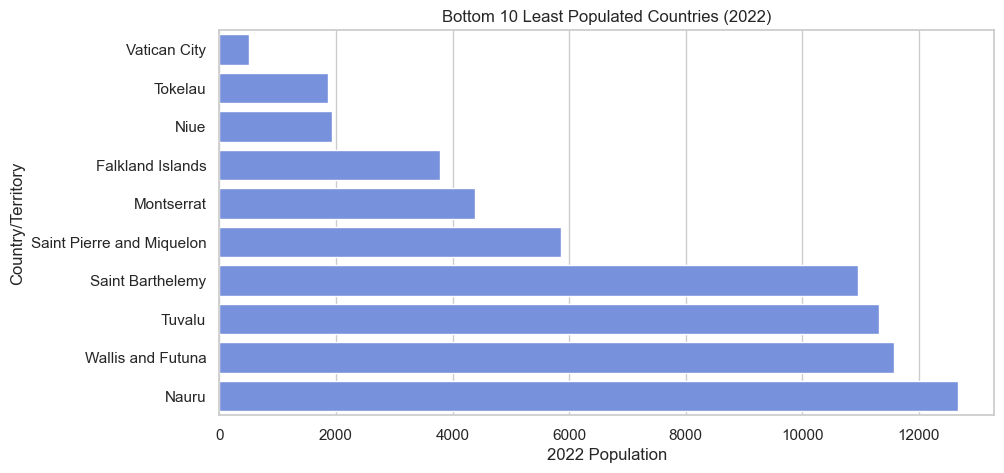

In [12]:
#Bottom 10 Least Populated Countries (2022)
bottom10 = df.sort_values("2022 Population", ascending=True).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=bottom10, x="2022 Population", y="Country/Territory")
plt.title("Bottom 10 Least Populated Countries (2022)")
plt.show()

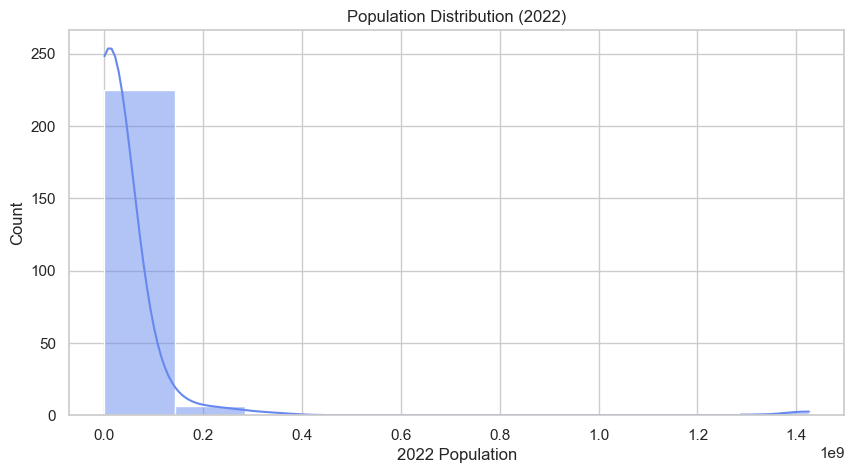

In [13]:
#Population Distribution (2022)
plt.figure(figsize=(10,5))
sns.histplot(df["2022 Population"], bins=10, kde=True)
plt.title("Population Distribution (2022)")
plt.show()

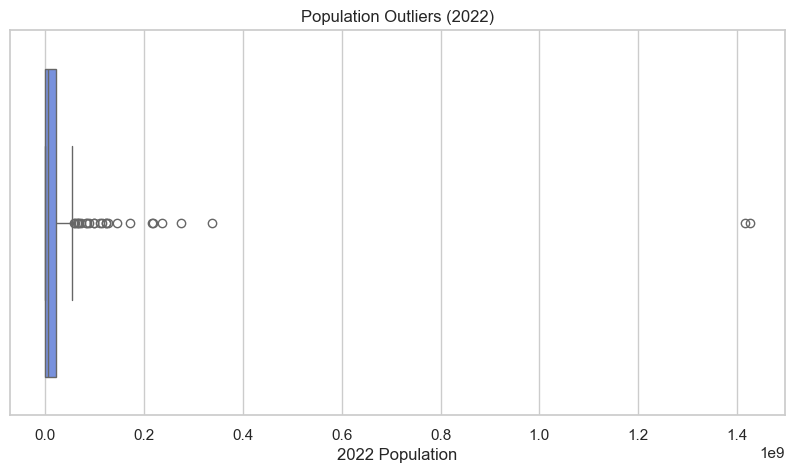

In [14]:
#Population Outliers (2022)
plt.figure(figsize=(10,5))
sns.boxplot(x=df["2022 Population"])
plt.title("Population Outliers (2022)")
plt.show()

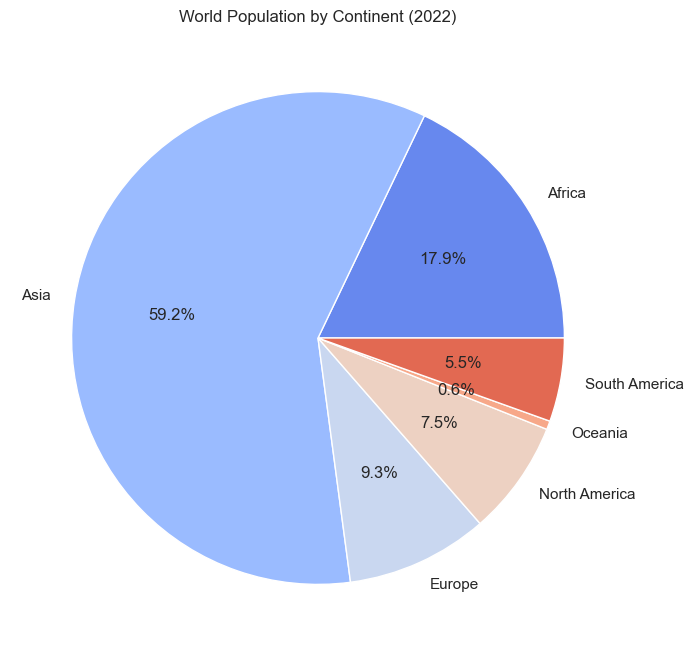

In [15]:
#World Population by Continent (2022)
continent_pop = df.groupby("Continent")["2022 Population"].sum()

plt.figure(figsize=(8,8))
plt.pie(continent_pop, labels=continent_pop.index, autopct="%1.1f%%")
plt.title("World Population by Continent (2022)")
plt.show()

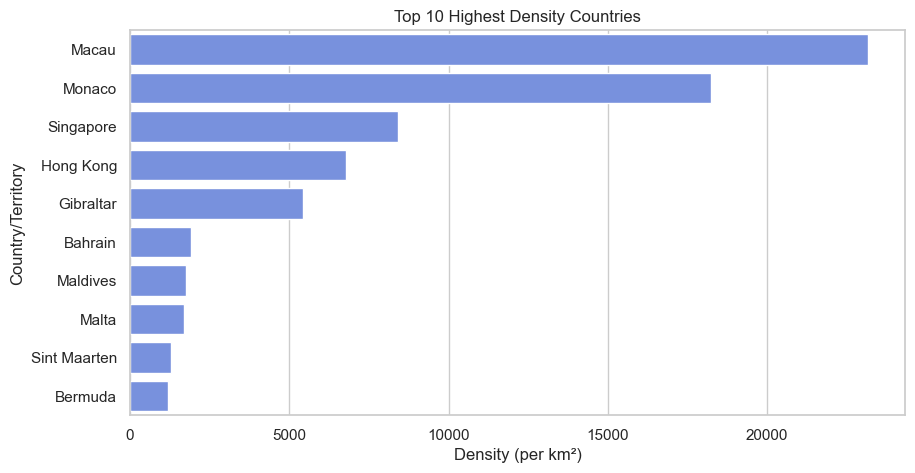

In [16]:
#Top 10 Highest Density Countries
top_density = df.sort_values("Density (per km²)", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top_density, x="Density (per km²)", y="Country/Territory")
plt.title("Top 10 Highest Density Countries")
plt.show()

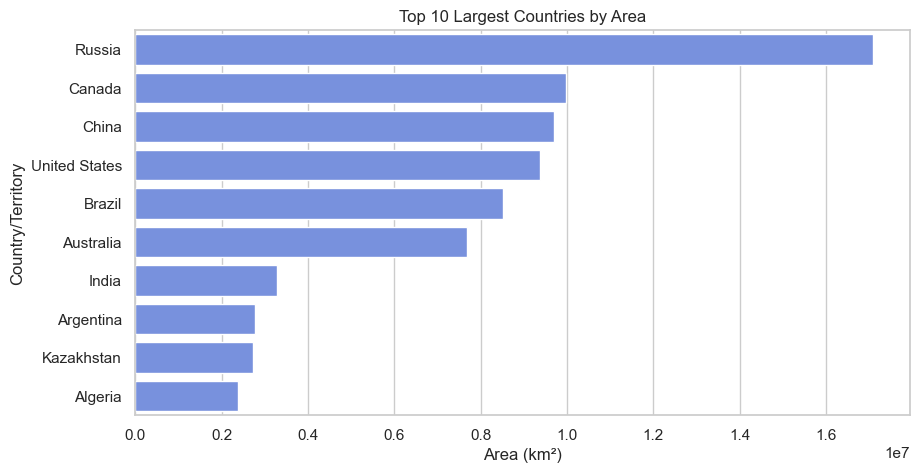

In [17]:
#Top 10 Largest Countries by Area
top_area = df.sort_values("Area (km²)", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top_area, x="Area (km²)", y="Country/Territory")
plt.title("Top 10 Largest Countries by Area")
plt.show()

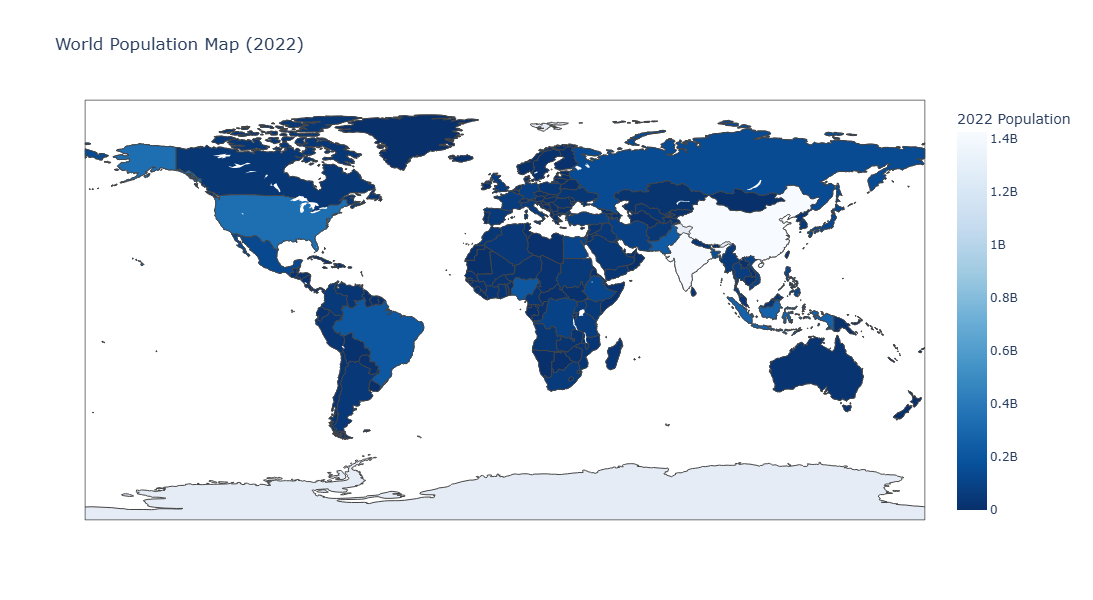

In [24]:

fig = px.choropleth(
    df,
    locations="CCA3",
    color="2022 Population",
    hover_name="Country/Territory",
    color_continuous_scale="Blues_",
    title = "World Population Map (2022)",
    width=1000,  
    height=600    
)

fig.show()